In [26]:
import preprocessing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import HistGradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.inspection import permutation_importance
# https://datascience.stackexchange.com/questions/30881/when-is-precision-more-important-over-recall
# https://scikit-learn.org/stable/auto_examples/applications/plot_time_series_lagged_features.html
# duplicate timestamps, missing timestamps (NaNs)

In [2]:
df_op = preprocessing.preprocessing_operating_data()

/Users/kamalrajanisrani/Documents/MSc Advanced Machine Learning/Semester 1/Applied Machine Learning/Coursework/Applied/preprocessing.py:7: DtypeWarning: Columns (2,3,4,5,6,7,9,10,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df_op = pd.read_csv(r'4000 series operating data.csv')


In [3]:
df_p = preprocessing.preprocessing_product_data()

## Task 2

In [4]:
df_product_rate_per_batch = (
    df_op.groupby('Batch')['TOTAL LIQUID'].mean() * df_p.groupby('Batch')['Product (g/litre)'].mean()
    *
    0.001)
display(df_product_rate_per_batch)

Batch
4030    616.305179
4032    621.162886
4033    608.869223
4034    622.196071
4035    606.416985
4036    609.172327
4037    568.419365
4038    593.373544
4039    581.763278
4040     651.30302
4041    670.229408
4042    645.844169
4043    669.367477
4044    621.672935
4045    640.864621
4046    644.787017
4047    663.092116
4048    596.268039
4050    536.552036
4051    549.661318
4052    629.353928
4053           NaN
dtype: object

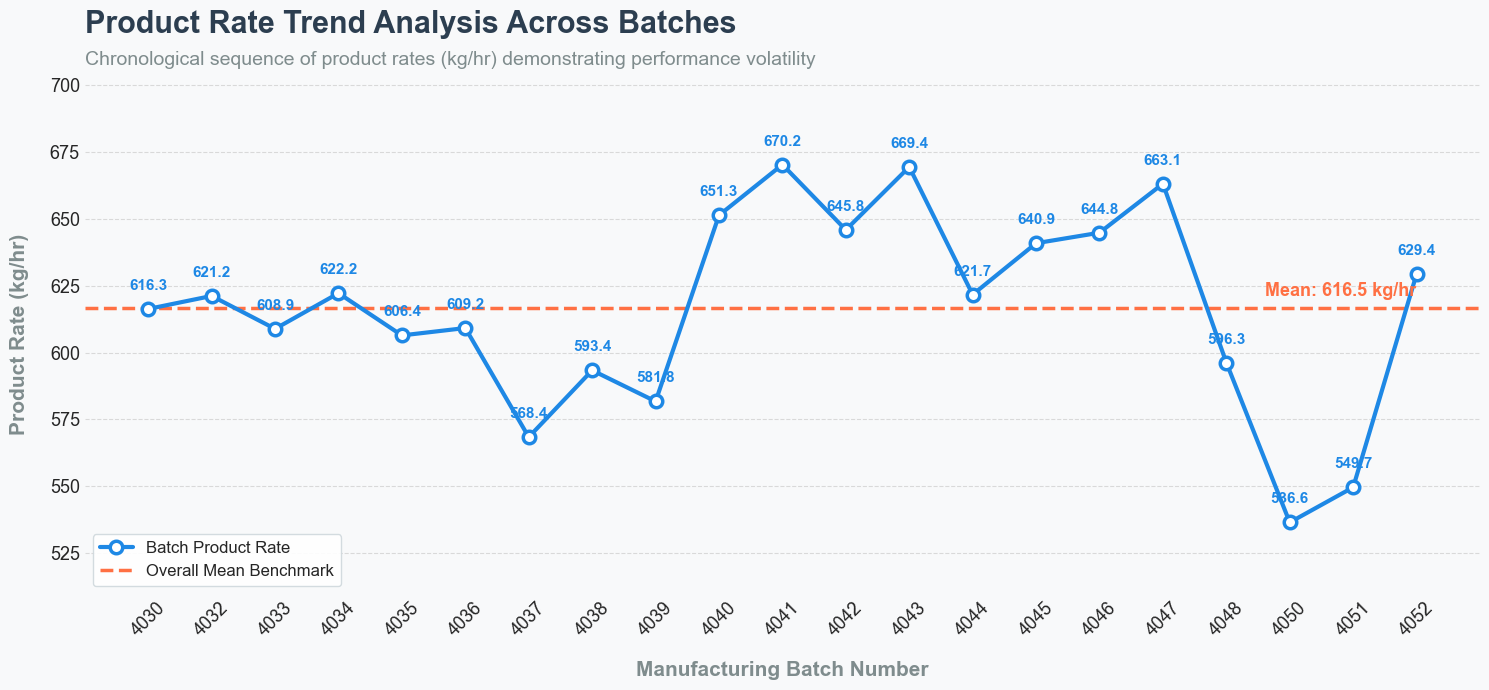

In [25]:
df_plot = df_product_rate_per_batch.dropna()

mean_rate = df_plot.mean()

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(15, 7))
fig.patch.set_facecolor('#f8f9fa')
ax.set_facecolor('#f8f9fa')

batches = df_plot.index.astype(str)
rates = df_plot.values

ax.plot(batches, rates, color='#1E88E5', marker='o', markersize=9, linewidth=3, 
        markerfacecolor='white', markeredgewidth=2.5, label='Batch Product Rate')

for i, rate in enumerate(rates):
    ax.text(i, rate + 6, f'{rate:.1f}', ha='center', va='bottom', 
            fontsize=11, color='#1E88E5', fontweight='bold')

ax.axhline(mean_rate, color='#FF7043', linestyle='--', linewidth=2.5, zorder=1, label='Overall Mean Benchmark')

ax.text(len(batches)-1, mean_rate + 3, f'Mean: {mean_rate:.1f} kg/hr', 
        color='#FF7043', fontweight='bold', fontsize=13, va='bottom', ha='right')

ax.set_title('Product Rate Trend Analysis Across Batches\n', fontsize=22, fontweight='bold', color='#2c3e50', loc='left')

ax.text(0, 1.02, 'Chronological sequence of product rates (kg/hr) demonstrating performance volatility', 
        transform=ax.transAxes, fontsize=14, color='#7f8c8d')

ax.set_xlabel('Manufacturing Batch Number', fontsize=15, color='#7f8c8d', labelpad=15, fontweight='bold')
ax.set_ylabel('Product Rate (kg/hr)', fontsize=15, color='#7f8c8d', labelpad=15, fontweight='bold')

ax.tick_params(axis='x', labelsize=13, rotation=45)
ax.tick_params(axis='y', labelsize=13)

ax.set_ylim(min(rates) * 0.95, max(rates) * 1.05)

ax.grid(True, axis='y', linestyle='--', alpha=0.7)
ax.grid(False, axis='x') 
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(False)

ax.legend(loc='lower left', fontsize=12, frameon=True, 
          facecolor='white', framealpha=0.9, edgecolor='#CFD8DC')

plt.tight_layout()
plt.savefig("product_rate_trend_labelled_with_values.jpeg", dpi=300, bbox_inches='tight', facecolor='#f8f9fa')
plt.show()

## Task 3

In [6]:
df_product_rate_per_batch.sort_values(ascending=False)

Batch
4041    670.229408
4043    669.367477
4047    663.092116
4040     651.30302
4042    645.844169
4046    644.787017
4045    640.864621
4052    629.353928
4034    622.196071
4044    621.672935
4032    621.162886
4030    616.305179
4036    609.172327
4033    608.869223
4035    606.416985
4048    596.268039
4038    593.373544
4039    581.763278
4037    568.419365
4051    549.661318
4050    536.552036
4053           NaN
dtype: object

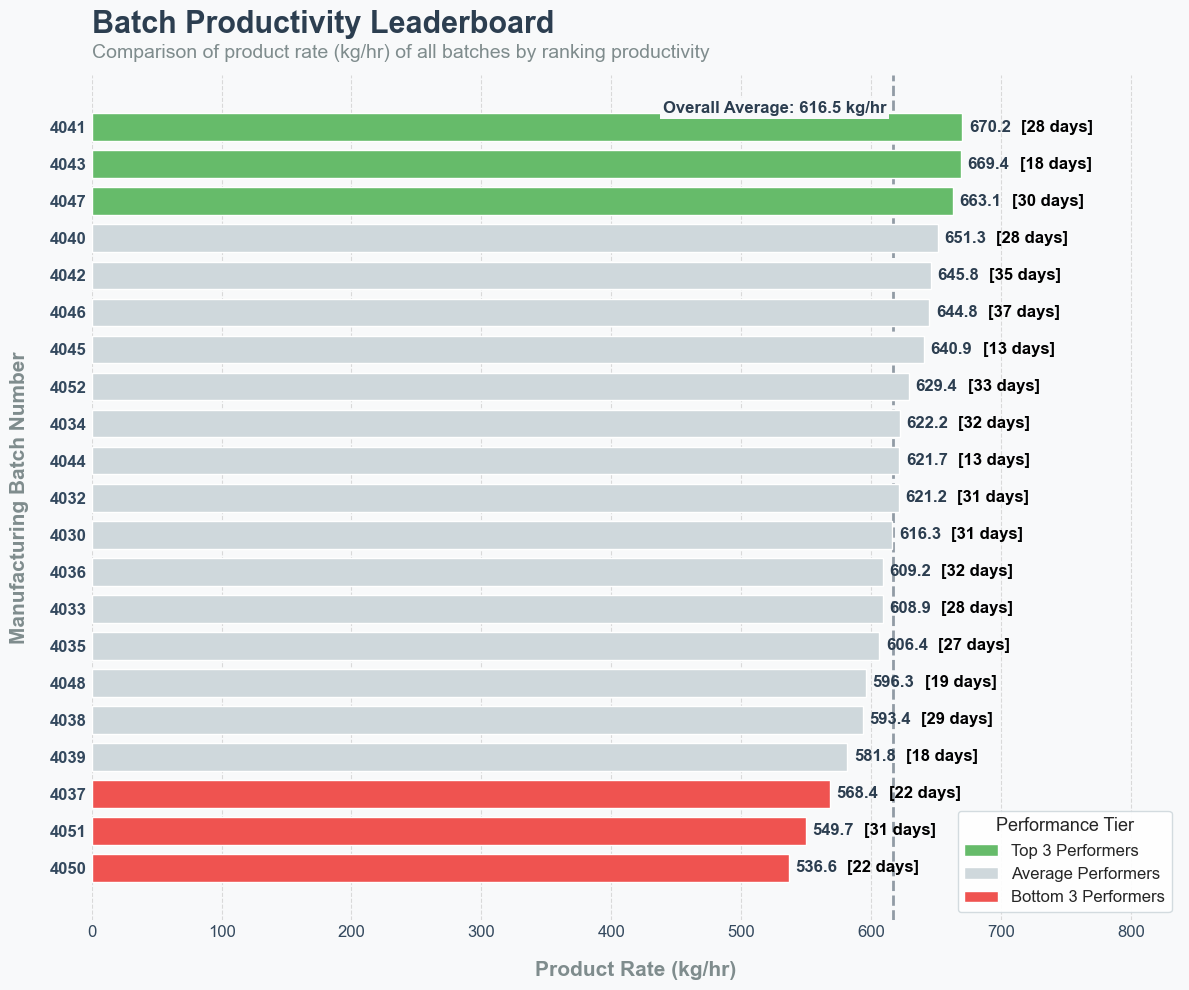

In [7]:
df_durations = preprocessing.duration_summary_operating_batches(df_op)

df_combined = pd.DataFrame({
    'Rate': df_product_rate_per_batch,
    'Duration': df_durations
}).dropna().sort_values(by='Rate', ascending=True)

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 10))
fig.patch.set_facecolor('#f8f9fa')
ax.set_facecolor('#f8f9fa')

colors = []
for i in range(len(df_combined)):
    if i < 3: 
        colors.append('#EF5350')
    elif i >= len(df_combined) - 3: 
        colors.append('#66BB6A')
    else:
        colors.append('#CFD8DC')

bars = ax.barh(df_combined.index.astype(str), df_combined['Rate'], color=colors, edgecolor='white', height=0.75)

for bar, batch_id in zip(bars, df_combined.index):
    width = bar.get_width()
    duration_days = int(df_combined.loc[batch_id, 'Duration'])
    
    
    ax.text(width + 5, bar.get_y() + bar.get_height()/2, f'{width:.1f}', 
            va='center', ha='left', color='#2c3e50', fontweight='bold', fontsize=12)
    
    text_offset = 40 
    ax.text(width + 5 + text_offset, bar.get_y() + bar.get_height()/2, f'[{duration_days} days]', 
            va='center', ha='left', color='black', fontweight='bold', fontsize=12)

mean_val = df_combined['Rate'].mean()
ax.axvline(mean_val, color='#2c3e50', linestyle='--', linewidth=2, alpha=0.5, zorder=0)
ax.text(mean_val - 5, len(df_combined) - 0.5, f'Overall Average: {mean_val:.1f} kg/hr', 
        color='#2c3e50', fontweight='bold', fontsize=12, va='center', ha='right',
        bbox=dict(facecolor='#f8f9fa', edgecolor='none', pad=2))

ax.set_title('Batch Productivity Leaderboard\n', fontsize=22, fontweight='bold', color='#2c3e50', loc='left')
ax.text(0, 1.02, 'Comparison of product rate (kg/hr) of all batches by ranking productivity', 
        transform=ax.transAxes, fontsize=14, color='#7f8c8d')

ax.set_xlabel('Product Rate (kg/hr)', fontsize=15, color='#7f8c8d', labelpad=15, fontweight='bold')
ax.set_ylabel('Manufacturing Batch Number', fontsize=15, color='#7f8c8d', labelpad=15, fontweight='bold')


legend_elements = [
    Patch(facecolor='#66BB6A', edgecolor='white', label='Top 3 Performers'),
    Patch(facecolor='#CFD8DC', edgecolor='white', label='Average Performers'),
    Patch(facecolor='#EF5350', edgecolor='white', label='Bottom 3 Performers')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=12, frameon=True, 
          facecolor='white', framealpha=0.9, edgecolor='#CFD8DC', title='Performance Tier', title_fontsize=13)

ax.set_xlim(0, max(df_combined['Rate']) * 1.25)
ax.grid(True, axis='x', linestyle='--', alpha=0.7)
ax.grid(False, axis='y')
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(False)

plt.yticks(fontsize=12, color='#34495e', fontweight='bold')
plt.xticks(fontsize=12, color='#34495e')

plt.tight_layout()
plt.savefig("batch_productivity_with_duration.jpeg", dpi=300, bbox_inches='tight', facecolor='#f8f9fa')
plt.show()

In [8]:
df_op.columns

Index(['Date and time', 'Batch', 'LIQUID', 'LIQUID.1', 'LIQUID.2', 'LIQUID.3',
       'LIQUID.4', 'LIQUID.5', 'pH', 'GAS', 'GAS.1', 'GAS.2', 'GAS.3',
       'OFFGAS', 'OFFGAS.1', 'PRESSURE', 'PRESSURE.1', 'OXYGEN',
       'TOTAL LIQUID'],
      dtype='object')

In [9]:
df_op = preprocessing.add_product_to_operating(df_op, df_p)

In [10]:
df_op.columns

Index(['Date and time', 'Batch', 'LIQUID', 'LIQUID.1', 'LIQUID.2', 'LIQUID.3',
       'LIQUID.4', 'LIQUID.5', 'pH', 'GAS', 'GAS.1', 'GAS.2', 'GAS.3',
       'OFFGAS', 'OFFGAS.1', 'PRESSURE', 'PRESSURE.1', 'OXYGEN',
       'TOTAL LIQUID', 'Product (g/litre)'],
      dtype='object')

In [11]:
#df_op.to_csv('4000 series operating data product.csv')

In [12]:
# df_op = pd.read_csv('4000 series operating data product.csv')
# df_op['Date and time'] = pd.to_datetime(df_op['Date and time'])

In [13]:
#df_op.drop(columns=['Unnamed: 0'], inplace=True)

In [14]:
df_op = df_op.sort_values(['Batch', 'Date and time'])

In [15]:
# Adding lag features in the dataset

for i in range(4):
    df_op[f'LIQUID_lag{i+1}'] = df_op.groupby('Batch')['LIQUID'].shift(i+1)
    df_op[f'LIQUID.1_lag{i+1}'] = df_op.groupby('Batch')['LIQUID.1'].shift(i+1)
    df_op[f'LIQUID.2_lag{i+1}'] = df_op.groupby('Batch')['LIQUID.2'].shift(i+1)
    df_op[f'LIQUID.3_lag{i+1}'] = df_op.groupby('Batch')['LIQUID.3'].shift(i+1)
    df_op[f'LIQUID.4_lag{i+1}'] = df_op.groupby('Batch')['LIQUID.4'].shift(i+1)
    df_op[f'LIQUID.5_lag{i+1}'] = df_op.groupby('Batch')['LIQUID.5'].shift(i+1)

    df_op[f'GAS_lag{i+1}'] = df_op.groupby('Batch')['GAS'].shift(i+1)
    df_op[f'GAS.1_lag{i+1}'] = df_op.groupby('Batch')['GAS.1'].shift(i+1)
    df_op[f'GAS.2_lag{i+1}'] = df_op.groupby('Batch')['GAS.2'].shift(i+1)
    df_op[f'GAS.3_lag{i+1}'] = df_op.groupby('Batch')['GAS.3'].shift(i+1)
    
for i in range(2):
    df_op[f'pH_lag{i+1}'] = df_op.groupby('Batch')['pH'].shift(i+1)
    df_op[f'OFFGAS_lag{i+1}'] = df_op.groupby('Batch')['OFFGAS'].shift(i+1)
    df_op[f'OFFGAS.1_lag{i+1}'] = df_op.groupby('Batch')['OFFGAS.1'].shift(i+1)
    df_op[f'PRESSURE_lag{i+1}'] = df_op.groupby('Batch')['PRESSURE'].shift(i+1)
    df_op[f'PRESSURE.1_lag{i+1}'] = df_op.groupby('Batch')['PRESSURE.1'].shift(i+1)
    df_op[f'OXYGEN_lag{i+1}'] = df_op.groupby('Batch')['OXYGEN'].shift(i+1)


In [16]:
batch_start = df_op.groupby('Batch')['Date and time'].transform('min')

df_op['Time Since Batch Start'] = (((df_op['Date and time'] - batch_start).dt.total_seconds() / 3600).round(2))
df_op['Time Diff in Batch'] = ((df_op.groupby('Batch')['Date and time'].diff().dt.total_seconds() / 60).round(2))

In [17]:
df_op['Product (g/litre)'] = df_op.pop('Product (g/litre)')

In [18]:
# Training set comprises of batches from 4030 - 4050 which have non-null values
df_op_train = df_op[(df_op['Batch'].between(4030, 4050)) & (df_op['Product (g/litre)'].notna())]

# Validation set comprises of batches 4051 & 4052 which have non-null values
df_op_val = df_op[(df_op['Batch'].isin([4051, 4052])) & (df_op['Product (g/litre)'].notna())]

df_op_test = df_op[((df_op['Batch'].between(4030, 4052) & df_op['Product (g/litre)'].isna()) |
        (df_op['Batch'] == 4053))]

In [19]:
target = 'Product (g/litre)'

drop_cols = ['Date and time', 'Batch', target]
feature_cols = [c for c in df_op_train.columns if c not in drop_cols]

X_train = df_op_train[feature_cols]
y_train = df_op_train[target]

X_val = df_op_val[feature_cols]
y_val = df_op_val[target]

In [20]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=8,
    gamma=1,
    subsample=0.7,
    colsample_bytree=0.6,
    reg_alpha=4,
    reg_lambda=10,
    random_state=42
)

xgb_model.fit(X_train, y_train)
y_val_pred_xgb = xgb_model.predict(X_val)
y_train_pred_xgb = xgb_model.predict(X_train)

histgradbr_model = HistGradientBoostingRegressor(
    max_iter=75,
    learning_rate=0.1,
    max_depth=6,
    min_samples_leaf=8,
    l2_regularization=11,
    max_bins=255,
    random_state=42
)

histgradbr_model.fit(X_train, y_train)

y_val_pred_histgradbr = histgradbr_model.predict(X_val)
y_train_pred_histgradbr = histgradbr_model.predict(X_train)

print("Validation MAE for XGBoost:", mean_absolute_error(y_val, y_val_pred_xgb))
print("Validation R2 for XGBoost:", r2_score(y_val, y_val_pred_xgb))

print("Validation MAE for HistGradientBoostingRegressor:", mean_absolute_error(y_val, y_val_pred_histgradbr))
print("Validation R2 for HistGradientBoostingRegressor:", r2_score(y_val, y_val_pred_histgradbr))

Validation MAE for XGBoost: 1.5058081150054932
Validation R2 for XGBoost: 0.5854640603065491
Validation MAE for HistGradientBoostingRegressor: 1.657824124333748
Validation R2 for HistGradientBoostingRegressor: 0.489358363887085


In [21]:
def compute_rmse(model, df_op_test, df_op, df_product_rate_per_batch):
    
    # Prepare X_test
    X_test = df_op_test[X_train.columns]
    
    # Predict
    y_test_pred = model.predict(X_test).round(2)
    
    # Assign predictions safely
    df_op_test = df_op_test.copy()
    df_op_test.loc[:, 'Product_pred'] = y_test_pred
    
    # Merge back
    pred_map = df_op_test[['Date and time', 'Batch', 'Product_pred']]
    df_op_temp = df_op.merge(pred_map, on=['Date and time', 'Batch'], how='left')
    
    # Fill missing values
    mask = df_op_temp['Product (g/litre)'].isna()
    df_op_temp.loc[mask, 'Product (g/litre)'] = df_op_temp.loc[mask, 'Product_pred']
    
    df_op_temp = df_op_temp.drop(columns=['Product_pred'])
    
    
    # Predicted batch-level product rate
    df_product_rate_per_batch_pred = (
        df_op_temp.groupby('Batch')['TOTAL LIQUID'].mean() *
        df_op_temp.groupby('Batch')['Product (g/litre)'].mean() *
        0.001
    )
    
    # Align + drop 4053
    y_true = df_product_rate_per_batch.drop(4053)
    y_pred = df_product_rate_per_batch_pred.drop(4053)
    
    y_true, y_pred = y_true.align(y_pred, join='inner')
    
    # RMSE
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    return rmse

In [22]:
rmse_xgb = compute_rmse(xgb_model, df_op_test, df_op, df_product_rate_per_batch)
rmse_hist = compute_rmse(histgradbr_model, df_op_test, df_op, df_product_rate_per_batch)

print("XGB RMSE:", rmse_xgb)
print("HistGB RMSE:", rmse_hist)

XGB RMSE: 9.543376888029998
HistGB RMSE: 8.893326753479666


In [23]:
importance = xgb_model.feature_importances_

pairs = sorted(zip(X_train.columns, importance), key=lambda x: x[1], reverse=True)

for feature, imp in pairs:
    print(feature, imp)

LIQUID.4 0.32332268
LIQUID_lag4 0.1013545
LIQUID.4_lag4 0.0763931
LIQUID.4_lag2 0.05901338
GAS.3_lag4 0.03839223
LIQUID_lag3 0.03822787
LIQUID.1_lag3 0.028683595
LIQUID 0.026301377
GAS.3_lag3 0.02065541
GAS.3 0.018832937
LIQUID_lag1 0.016344564
LIQUID_lag2 0.0155497445
LIQUID.1_lag4 0.0130407335
LIQUID.2_lag4 0.011571545
Time Diff in Batch 0.009495624
LIQUID.2 0.009000964
OFFGAS_lag1 0.008099014
LIQUID.5_lag1 0.008092285
OFFGAS_lag2 0.007367708
GAS 0.0071019274
GAS_lag2 0.00706558
LIQUID.3_lag2 0.006646801
LIQUID.1_lag2 0.0065459614
GAS_lag3 0.0062747602
LIQUID.2_lag3 0.005954858
LIQUID.3_lag1 0.0059390366
OFFGAS 0.0058513773
LIQUID.4_lag3 0.005664547
GAS_lag1 0.005564807
GAS.3_lag1 0.0053048367
LIQUID.5 0.0051823026
OFFGAS.1_lag1 0.004681118
LIQUID.3_lag3 0.004625917
LIQUID.3 0.004567147
LIQUID.3_lag4 0.004299627
LIQUID.5_lag4 0.0039321836
OXYGEN_lag1 0.0038326893
OXYGEN_lag2 0.0037144008
LIQUID.5_lag2 0.0034060497
GAS_lag4 0.0033114974
PRESSURE.1_lag1 0.0032752159
LIQUID.5_lag3 0.003

In [27]:
result = permutation_importance(
    histgradbr_model,
    X_train,
    y_train,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importance = result.importances_mean

pairs = sorted(zip(X_train.columns, importance), key=lambda x: x[1], reverse=True)

for feature, imp in pairs:
    print(feature, imp)

LIQUID_lag4 0.08108636234900396
GAS.3_lag4 0.06255066833299328
LIQUID.4 0.049173055334881546
Time Diff in Batch 0.044223410798429764
Time Since Batch Start 0.018272925774158157
LIQUID_lag2 0.01674462946256967
GAS.3 0.014991589698070207
LIQUID 0.014566125612131076
OFFGAS_lag2 0.013490736781096769
LIQUID.3_lag3 0.01320742593208255
GAS 0.011416113203337575
LIQUID.1_lag3 0.011369760353177138
OFFGAS_lag1 0.010777358291780458
LIQUID_lag1 0.00941593126658553
LIQUID.5_lag1 0.008618205287959068
LIQUID.3_lag2 0.008162966042943065
LIQUID.3 0.0074654058708461205
OXYGEN_lag1 0.0073596847538331175
LIQUID.3_lag1 0.007144230685364383
GAS_lag2 0.0067834590706213225
LIQUID.2_lag1 0.006611194186002534
OFFGAS.1_lag2 0.006391465702459775
LIQUID.5_lag4 0.005815719857727386
GAS.1_lag2 0.005756443993615157
LIQUID.4_lag3 0.005562392453883025
LIQUID_lag3 0.005251771319420307
LIQUID.5 0.00521038712753018
OFFGAS.1 0.004575046898559554
GAS_lag4 0.004440989408955542
LIQUID.4_lag2 0.0043555195573358185
PRESSURE.1 0.